# 🩺 Multi-Modal Eye Disease Classification
## Vision-Language Fusion with InceptionV3 + BERT

**Project Overview:**  
This notebook implements a multi-modal deep learning pipeline that classifies eye diseases  
by fusing:
- **Visual features** extracted via InceptionV3 (from fundus/eye images)
- **Textual features** from patient symptom descriptions via BERT

**Supported Classes:**
| Index | Disease |
|-------|---------|
| 0 | Glaucoma |
| 1 | Cataract |
| 2 | Retinal Disease (Diabetic Retinopathy) |
| 3 | Normal |

**Architecture:** FusionClassifier = BERT encoder + InceptionV3 projector → MLP classifier

---


## 📦 1. Install Dependencies

In [1]:
# Install all required packages
!pip install -q pandas transformers scikit-learn matplotlib seaborn tqdm
!pip install -q tensorflow torch torchvision
!pip install -q Pillow

import subprocess
print("✅ All packages installed.")


✅ All packages installed.


## 🔗 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted.")


Mounted at /content/drive
✅ Google Drive mounted.


## ⚙️ 3. Configuration & Constants

All project-wide paths, hyperparameters, and settings are defined here.  
**Modify these paths to match your Google Drive structure.**


In [3]:
import os

# ── Dataset Paths ──────────────────────────────────────────────────────────
DATASET_DIR         = '/content/drive/MyDrive/Dataset'
CAPTIONS_DIR        = '/content/drive/MyDrive/Captions and img feature'
FEATURES_PATH       = os.path.join(CAPTIONS_DIR, 'inception_features.npy')
LABELS_PATH         = os.path.join(CAPTIONS_DIR, 'inception_labels.npy')
FILENAMES_PATH      = os.path.join(DATASET_DIR,   'image_filenames.npy')
MODEL_SAVE_PATH     = '/content/drive/MyDrive/fusion_classifier.pth'
LABEL_ENCODER_PATH  = '/content/drive/MyDrive/label_encoder_classes.npy'

# ── Model Hyperparameters ─────────────────────────────────────────────────
IMAGE_SIZE      = (299, 299)    # InceptionV3 input size
MAX_TEXT_LEN    = 50            # Max BERT token length
BATCH_SIZE      = 32
LEARNING_RATE   = 1e-4
NUM_EPOCHS      = 10            # Increased for better convergence
DROPOUT_RATE    = 0.3
HIDDEN_DIM      = 512

# ── Class Mapping ─────────────────────────────────────────────────────────
DIAGNOSIS_MAP = {
    0: "Glaucoma",
    1: "Cataract",
    2: "Retinal Disease",
    3: "Normal"
}

print("✅ Configuration loaded.")
print(f"   Dataset dir : {DATASET_DIR}")
print(f"   Features    : {FEATURES_PATH}")
print(f"   Labels      : {LABELS_PATH}")
print(f"   Epochs      : {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")


✅ Configuration loaded.
   Dataset dir : /content/drive/MyDrive/Dataset
   Features    : /content/drive/MyDrive/Captions and img feature/inception_features.npy
   Labels      : /content/drive/MyDrive/Captions and img feature/inception_labels.npy
   Epochs      : 10, Batch: 32, LR: 0.0001


## 📚 4. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import os, glob, json, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import BertTokenizer, BertModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries imported | Device: {device}")


✅ Libraries imported | Device: cuda


## 🖼️ 5. Extract Image Filenames from Dataset

Scans the dataset directory (subfolders = class names) and saves image filenames.


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator()
generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Extract just the basenames (no class-folder prefix)
image_filenames = [os.path.basename(f).strip().lower()
                   for f in generator.filenames]

# Persist for alignment with features
np.save(FILENAMES_PATH, image_filenames)
print(f"✅ Saved {len(image_filenames)} image filenames to {FILENAMES_PATH}")
print(f"   Sample: {image_filenames[:5]}")


Found 4385 images belonging to 4 classes.
✅ Saved 4385 image filenames to /content/drive/MyDrive/Dataset/image_filenames.npy
   Sample: ['036.jpg', '037.jpg', '041.jpg', '050.jpg', '069.jpg']


## 📝 6. Load & Align Captions

Reads all caption CSV files from `CAPTIONS_DIR` and aligns them with image filenames.  
Expected CSV schema: `image`, `caption`


In [6]:
# ── Load Caption CSVs ─────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(CAPTIONS_DIR, '*.csv'))
caption_map = {}

if not csv_files:
    print(f"⚠️  No CSV files found in: {CAPTIONS_DIR}")
else:
    for fpath in csv_files:
        df = pd.read_csv(fpath)
        if 'image' in df.columns and 'caption' in df.columns:
            for img, cap in zip(df['image'], df['caption']):
                key = os.path.basename(str(img)).strip().lower()
                caption_map[key] = str(cap)
        else:
            print(f"⚠️  Skipping {fpath} — missing 'image' or 'caption' column")
    print(f"✅ Loaded {len(caption_map)} caption entries from {len(csv_files)} CSV(s)")

# ── Align with Image Filenames ────────────────────────────────────────────
image_filenames = np.load(FILENAMES_PATH, allow_pickle=True).tolist()

caption_texts = []
missing = 0
for fname in image_filenames:
    if fname in caption_map:
        caption_texts.append(caption_map[fname])
    else:
        caption_texts.append("No caption available for this eye image.")
        missing += 1

print(f"✅ Aligned {len(caption_texts)} captions  |  ⚠️  Missing: {missing}")


✅ Loaded 4182 caption entries from 4 CSV(s)
✅ Aligned 4385 captions  |  ⚠️  Missing: 201


## 🔢 7. Load Image Features & Labels

Loads pre-extracted InceptionV3 features and class labels, then filters to  
keep only samples that have corresponding captions.


In [7]:
# ── Load Features ─────────────────────────────────────────────────────────
image_features = np.load(FEATURES_PATH)   # shape (N, 2048)
labels_raw     = np.load(LABELS_PATH)     # shape (N,) or (N, num_classes)

if labels_raw.ndim > 1:
    labels_raw = np.argmax(labels_raw, axis=1)

print(f"Image features : {image_features.shape}")
print(f"Labels         : {labels_raw.shape}  | unique: {np.unique(labels_raw)}")
print(f"Image filenames: {len(image_filenames)}")

# ── Filter to Valid (has caption) Samples ────────────────────────────────
valid_feats, valid_caps, valid_labels = [], [], []

for i, fname in enumerate(image_filenames):
    if fname in caption_map and i < len(image_features):
        valid_feats.append(image_features[i])
        valid_caps.append(caption_map[fname])
        valid_labels.append(labels_raw[i])

image_features = np.array(valid_feats)
caption_texts  = valid_caps
labels         = np.array(valid_labels)

print(f"\n✅ After filtering:")
print(f"   Features : {image_features.shape}")
print(f"   Captions : {len(caption_texts)}")
print(f"   Labels   : {labels.shape}  | unique: {np.unique(labels)}")
assert len(image_features) == len(caption_texts) == len(labels), "Length mismatch!"


Image features : (4385, 2048)
Labels         : (4385,)  | unique: [1 2 3 4]
Image filenames: 4385

✅ After filtering:
   Features : (4184, 2048)
   Captions : 4184
   Labels   : (4184,)  | unique: [1 2 3 4]


## 📊 8. Exploratory Data Analysis (EDA)

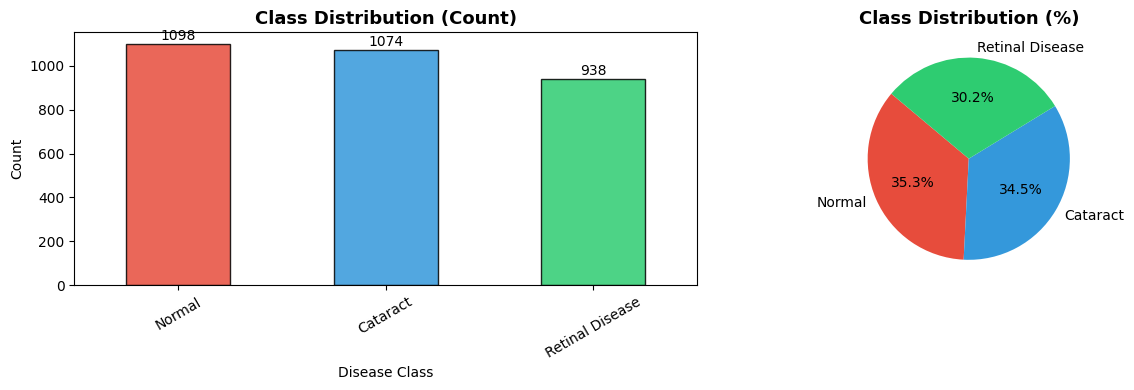

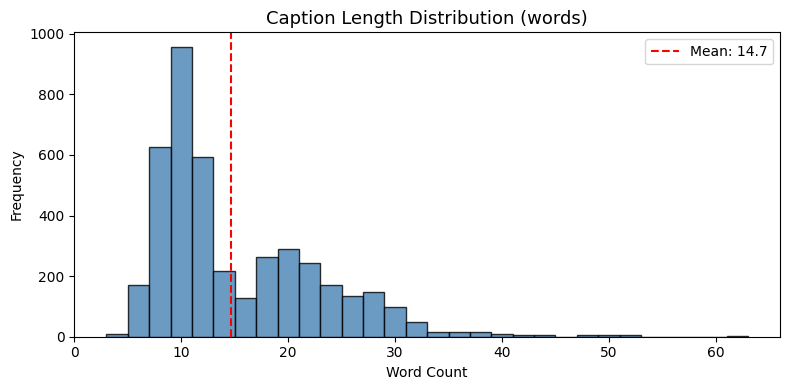

✅ EDA complete
   Total samples : 4184
   Avg cap length: 14.7 words  |  Max: 63


In [8]:
# ── Class Distribution ────────────────────────────────────────────────────
label_counts = pd.Series(labels).map(DIAGNOSIS_MAP).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71','#f39c12'],
                  edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disease Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#2ecc71','#f39c12'], startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Caption Length Distribution ───────────────────────────────────────────
cap_lengths = [len(c.split()) for c in caption_texts]
plt.figure(figsize=(8, 4))
plt.hist(cap_lengths, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(np.mean(cap_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(cap_lengths):.1f}')
plt.title('Caption Length Distribution (words)', fontsize=13)
plt.xlabel('Word Count'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout()
plt.show()

print(f"✅ EDA complete")
print(f"   Total samples : {len(labels)}")
print(f"   Avg cap length: {np.mean(cap_lengths):.1f} words  |  Max: {max(cap_lengths)}")


## ✂️ 9. Normalize Labels

Labels loaded from the .npy file may be 1-indexed or have an offset.  
We shift them to 0-indexed so they map correctly to `DIAGNOSIS_MAP`.


In [9]:
unique_labels = np.unique(labels)
print(f"Labels before normalization: {unique_labels}")

# Shift to 0-indexed if needed
if unique_labels.min() == 1:
    labels = labels - 1
    print(f"Labels shifted -1  →  {np.unique(labels)}")
else:
    print("Labels already 0-indexed — no shift needed.")

num_classes = len(np.unique(labels))
print(f"\n✅ num_classes = {num_classes}")
for idx, name in DIAGNOSIS_MAP.items():
    count = np.sum(labels == idx)
    print(f"   Class {idx} ({name:20s}): {count} samples")


Labels before normalization: [1 2 3 4]
Labels shifted -1  →  [0 1 2 3]

✅ num_classes = 4
   Class 0 (Glaucoma            ): 1074 samples
   Class 1 (Cataract            ): 938 samples
   Class 2 (Retinal Disease     ): 1098 samples
   Class 3 (Normal              ): 1074 samples


## 🔤 10. Tokenize Captions (BERT)

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenized = tokenizer(
    caption_texts,
    padding='max_length',
    truncation=True,
    max_length=MAX_TEXT_LEN,
    return_tensors='pt'
)

print(f"✅ Tokenized {len(caption_texts)} captions")
print(f"   input_ids shape     : {tokenized['input_ids'].shape}")
print(f"   attention_mask shape: {tokenized['attention_mask'].shape}")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenized 4184 captions
   input_ids shape     : torch.Size([4184, 50])
   attention_mask shape: torch.Size([4184, 50])


## 🗂️ 11. Custom PyTorch Dataset

In [11]:
class MultimodalDataset(Dataset):
    """Dataset combining InceptionV3 image features with BERT-tokenized captions."""

    def __init__(self, image_feats, text_tokens, labels):
        self.img_feats  = torch.tensor(image_feats, dtype=torch.float32)
        self.input_ids  = text_tokens['input_ids']
        self.attn_mask  = text_tokens['attention_mask']
        self.labels     = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'image'         : self.img_feats[idx],
            'input_ids'     : self.input_ids[idx],
            'attention_mask': self.attn_mask[idx],
            'label'         : self.labels[idx]
        }

print("✅ MultimodalDataset class defined.")


✅ MultimodalDataset class defined.


## ✂️ 12. Train / Validation / Test Split & DataLoaders

In [12]:
indices = np.arange(len(labels))

# 80% train, 10% val, 10% test (stratified)
train_idx, temp_idx = train_test_split(indices, test_size=0.2,
                                        random_state=SEED, stratify=labels)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5,
                                        random_state=SEED, stratify=labels[temp_idx])

def make_subset(idxs):
    return MultimodalDataset(
        image_features[idxs],
        {k: v[idxs] for k, v in tokenized.items()},
        labels[idxs]
    )

train_data = make_subset(train_idx)
val_data   = make_subset(val_idx)
test_data  = make_subset(test_idx)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Dataset split:")
print(f"   Train : {len(train_data):,} samples  ({len(train_loader)} batches)")
print(f"   Val   : {len(val_data):,} samples  ({len(val_loader)} batches)")
print(f"   Test  : {len(test_data):,} samples  ({len(test_loader)} batches)")


✅ Dataset split:
   Train : 3,347 samples  (105 batches)
   Val   : 418 samples  (14 batches)
   Test  : 419 samples  (14 batches)


## 🧠 13. Fusion Classifier Model

**Architecture:**
- **Text branch**: BERT (`bert-base-uncased`) → 768-dim pooler output
- **Image branch**: Linear(2048 → 768) + ReLU
- **Fusion**: Concatenation → Linear(1536 → 512) → ReLU → Dropout → Linear(512 → num_classes)

Both modalities contribute equally to the fusion representation.


In [13]:
class FusionClassifier(nn.Module):
    """Multi-modal classifier fusing BERT text features with InceptionV3 image features."""

    def __init__(self, num_classes, hidden_dim=HIDDEN_DIM, dropout=DROPOUT_RATE):
        super().__init__()

        # ── Text Branch ─────────────────────────────────────────────────
        self.text_encoder = BertModel.from_pretrained('bert-base-uncased')

        # ── Image Branch ────────────────────────────────────────────────
        self.img_proj = nn.Sequential(
            nn.Linear(2048, 768),
            nn.ReLU(),
            nn.LayerNorm(768)
        )

        # ── Fusion Classifier ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(768 * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, image, input_ids, attention_mask):
        # Text features
        text_out = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).pooler_output                           # (B, 768)

        # Image features
        img_out = self.img_proj(image)            # (B, 768)

        # Concatenate & classify
        fused = torch.cat([text_out, img_out], dim=1)  # (B, 1536)
        return self.classifier(fused)             # (B, num_classes)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = FusionClassifier(num_classes).to(device)
print(f"✅ FusionClassifier built on {device}")
print(f"   Trainable parameters: {model.count_parameters():,}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ FusionClassifier built on cuda
   Trainable parameters: 111,976,708


## ⚙️ 14. Training Setup (Optimizer, Scheduler, Loss)

In [15]:
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Reduce LR when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                               patience=2)

loss_fn = nn.CrossEntropyLoss()

print(f"✅ Optimizer : Adam  (lr={LEARNING_RATE}, weight_decay=1e-5)")
print(f"   Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)")
print(f"   Loss      : CrossEntropyLoss")

✅ Optimizer : Adam  (lr=0.0001, weight_decay=1e-5)
   Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)
   Loss      : CrossEntropyLoss


## 🏋️ 15. Training Loop with Validation & Early Stopping

In [16]:
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_loss = float('inf')
early_stop_patience = 4
no_improve_epochs   = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]", leave=False)
    for batch in loop:
        imgs  = batch['image'].to(device)
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        lbls  = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(imgs, ids, masks)
        loss   = loss_fn(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * lbls.size(0)
        train_correct += (logits.argmax(1) == lbls).sum().item()
        train_total   += lbls.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / train_total
    avg_train_acc  = train_correct / train_total

    # ── Validate ───────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            imgs  = batch['image'].to(device)
            ids   = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            lbls  = batch['label'].to(device)

            logits = model(imgs, ids, masks)
            loss   = loss_fn(logits, lbls)

            val_loss    += loss.item() * lbls.size(0)
            val_correct += (logits.argmax(1) == lbls).sum().item()
            val_total   += lbls.size(0)

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total

    scheduler.step(avg_val_loss)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f}  Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}  Acc: {avg_val_acc:.4f}")

    # ── Checkpoint ────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        no_improve_epochs = 0
        print(f"   💾 Best model saved (val_loss={best_val_loss:.4f})")
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= early_stop_patience:
            print(f"\n⏹  Early stopping at epoch {epoch} (no improvement for {early_stop_patience} epochs)")
            break

print("\n✅ Training complete.")


Epoch  1/10 | Train Loss: 0.6606  Acc: 0.7619 | Val Loss: 0.2626  Acc: 0.9211
   💾 Best model saved (val_loss=0.2626)


Epoch  2/10 | Train Loss: 0.2484  Acc: 0.9125 | Val Loss: 0.2208  Acc: 0.9067
   💾 Best model saved (val_loss=0.2208)


Epoch  3/10 | Train Loss: 0.1432  Acc: 0.9528 | Val Loss: 0.2435  Acc: 0.9234


Epoch  4/10 | Train Loss: 0.1047  Acc: 0.9641 | Val Loss: 0.1467  Acc: 0.9641
   💾 Best model saved (val_loss=0.1467)


Epoch  5/10 | Train Loss: 0.0663  Acc: 0.9797 | Val Loss: 0.3100  Acc: 0.9426


Epoch  6/10 | Train Loss: 0.0539  Acc: 0.9842 | Val Loss: 0.2085  Acc: 0.9545


Epoch  7/10 | Train Loss: 0.0347  Acc: 0.9892 | Val Loss: 0.2333  Acc: 0.9450


Epoch  8/10 | Train Loss: 0.0127  Acc: 0.9964 | Val Loss: 0.1681  Acc: 0.9593

⏹  Early stopping at epoch 8 (no improvement for 4 epochs)

✅ Training complete.


## 📈 16. Training Curves

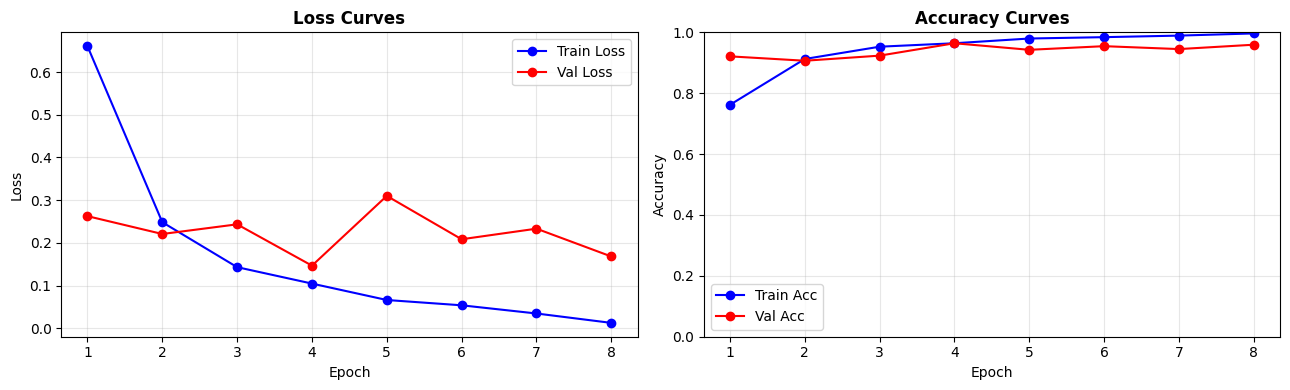

✅ Training curves saved.


In [17]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val Acc')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")


## 🧪 17. Evaluation on Test Set

In [18]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        imgs  = batch['image'].to(device)
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        lbls  = batch['label'].to(device)

        logits = model(imgs, ids, masks)
        probs  = F.softmax(logits, dim=1)

        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs   = np.array(all_probs)

acc = accuracy_score(all_targets, all_preds)
print(f"\n{'='*55}")
print(f"  ✅ Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"{'='*55}\n")

class_names = [DIAGNOSIS_MAP[i] for i in range(num_classes)]
print(classification_report(all_targets, all_preds, target_names=class_names))


Evaluating: 100%|██████████| 14/14 [00:01<00:00, 11.91it/s]


  ✅ Test Accuracy : 0.9284  (92.84%)

                 precision    recall  f1-score   support

       Glaucoma       0.90      0.94      0.92       108
       Cataract       0.97      0.90      0.93        93
Retinal Disease       0.95      0.96      0.95       110
         Normal       0.91      0.91      0.91       108

       accuracy                           0.93       419
      macro avg       0.93      0.93      0.93       419
   weighted avg       0.93      0.93      0.93       419



## 🗺️ 18. Confusion Matrix

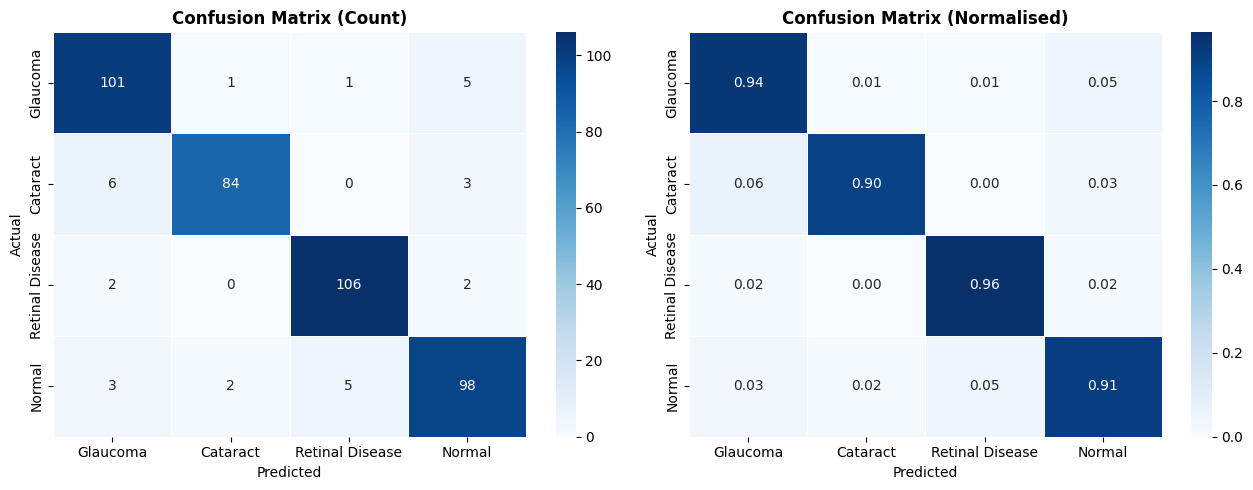

✅ Confusion matrix saved.


In [19]:
cm = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title, fmt in zip(
    axes,
    [cm,      cm_norm],
    ['Confusion Matrix (Count)', 'Confusion Matrix (Normalised)'],
    ['d',     '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, cbar=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved.")


## 📉 19. ROC Curves (One-vs-Rest)

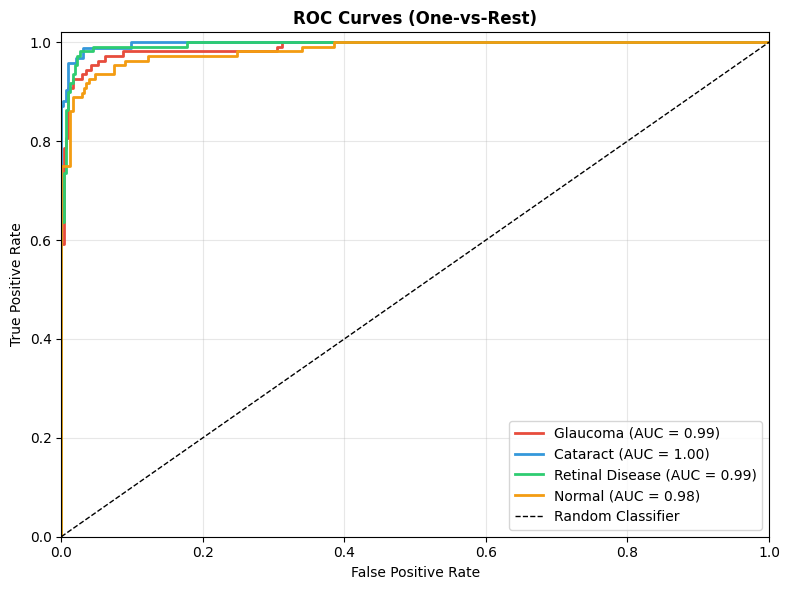

✅ ROC curves saved.


In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_bin = label_binarize(all_targets, classes=list(range(num_classes)))

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved.")


## 💾 20. Save Model & Artefacts

In [21]:
import json as _json

# ── Model weights are already saved in MODEL_SAVE_PATH ────────────────────

# ── Save training history as JSON ────────────────────────────────────────
history_path = '/content/drive/MyDrive/training_history.json'
with open(history_path, 'w') as f:
    _json.dump(history, f, indent=2)

# ── Save class mapping ────────────────────────────────────────────────────
map_path = '/content/drive/MyDrive/diagnosis_map.json'
with open(map_path, 'w') as f:
    _json.dump({str(k): v for k, v in DIAGNOSIS_MAP.items()}, f, indent=2)

print(f"✅ Artefacts saved:")
print(f"   Model weights   : {MODEL_SAVE_PATH}")
print(f"   Training history: {history_path}")
print(f"   Diagnosis map   : {map_path}")


✅ Artefacts saved:
   Model weights   : /content/drive/MyDrive/fusion_classifier.pth
   Training history: /content/drive/MyDrive/training_history.json
   Diagnosis map   : /content/drive/MyDrive/diagnosis_map.json


## 🔍 21. Inference Pipeline

Full end-to-end prediction function.  
Given an eye image path and a patient symptom caption, returns the predicted  
diagnosis class and confidence score.


In [22]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.inception_v3 import preprocess_input

# ── Build InceptionV3 Feature Extractor ──────────────────────────────────
base = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
inception_model = KerasModel(inputs=base.input,
                              outputs=GlobalAveragePooling2D()(base.output))
print("✅ InceptionV3 feature extractor ready.")

# ── Load best FusionClassifier ────────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()
print(f"✅ FusionClassifier loaded from {MODEL_SAVE_PATH}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ InceptionV3 feature extractor ready.
✅ FusionClassifier loaded from /content/drive/MyDrive/fusion_classifier.pth


In [24]:
def extract_image_feature(img_path: str) -> np.ndarray:
    """Extract 2048-dim InceptionV3 feature vector from a single image."""
    img = keras_image.load_img(img_path, target_size=IMAGE_SIZE)
    x   = preprocess_input(keras_image.img_to_array(img)[np.newaxis])
    return inception_model.predict(x, verbose=0)[0]   # (2048,)


def predict_diagnosis(img_path: str, caption: str,
                      top_k: int = 2) -> dict:
    """
    Run multi-modal inference.

    Returns
    -------
    dict with keys: predicted_class, diagnosis, confidence, all_probs
    """
    # ── Image feature ─────────────────────────────────────────────────
    img_feat   = extract_image_feature(img_path)
    img_tensor = torch.tensor(img_feat, dtype=torch.float32).unsqueeze(0).to(device)

    # ── Tokenize caption ──────────────────────────────────────────────
    tokens = tokenizer(caption, padding='max_length', truncation=True,
                       max_length=MAX_TEXT_LEN, return_tensors='pt')
    ids   = tokens['input_ids'].to(device)
    masks = tokens['attention_mask'].to(device)

    # ── Inference ─────────────────────────────────────────────────────
    with torch.no_grad():
        logits = model(img_tensor, ids, masks)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()

    pred_class = int(probs.argmax())
    confidence = float(probs.max())

    top_k_idx = probs.argsort()[::-1][:top_k]
    print(f"\n🩺 Prediction for: {os.path.basename(img_path)}")
    print(f"   Caption: '{caption[:80]}{'...' if len(caption)>80 else ''}'")
    print(f"   {'─'*50}")
    print(f"   ✅ Diagnosis : {DIAGNOSIS_MAP[pred_class]}")
    print(f"   Confidence  : {confidence:.2%}")
    print(f"   {'─'*50}")
    print(f"   Top-{top_k} breakdown:")
    for idx in top_k_idx:
        bar = '█' * int(probs[idx]*20)
        print(f"     {DIAGNOSIS_MAP[idx]:20s} {probs[idx]:.2%}  {bar}")

    return {
        'predicted_class': pred_class,
        'diagnosis'       : DIAGNOSIS_MAP[pred_class],
        'confidence'      : confidence,
        'all_probs'       : {DIAGNOSIS_MAP[i]: float(probs[i]) for i in range(num_classes)}
    }

## 🧪 22. Inference Examples

In [25]:
# ── Run all inference examples ─────────────────────────────
results = []
for img_path, caption, true_label in [
    ("/content/drive/MyDrive/Dataset/normal/2345_right.jpg", "I feel confident in my eyesight and have no concerns about vision loss", "Normal"),
    ("/content/drive/MyDrive/Dataset/Glaucoma/086.jpg", "My vision has become increasingly blurry and I notice halos around lights at night, making driving dangerous.", "Glaucoma"),
    ("/content/drive/MyDrive/Dataset/cataract/2154_left.jpg", "When I step outside into bright sunlight, the glare is overwhelming. My vision seems dull and foggy.", "Cataract"),
    ("/content/drive/MyDrive/Dataset/diabetic_retinopathy/10031_right.jpeg", "I have trouble judging distances because my vision is blurry and inconsistent. This affects my balance.", "Retinal Disease"),
    ("/content/drive/MyDrive/Dataset/normal/2334_right.jpg", "I can comfortably engage in visually demanding tasks without strain.", "Normal"),
]:
    result = predict_diagnosis(img_path, caption)
    result['true_label'] = true_label
    results.append(result)
    print()

print("\n✅ All inference examples complete.")



🩺 Prediction for: 2345_right.jpg
   Caption: 'I feel confident in my eyesight and have no concerns about vision loss'
   ──────────────────────────────────────────────────
   ✅ Diagnosis : Normal
   Confidence  : 99.99%
   ──────────────────────────────────────────────────
   Top-2 breakdown:
     Normal               99.99%  ███████████████████
     Retinal Disease      0.00%  


🩺 Prediction for: 086.jpg
   Caption: 'My vision has become increasingly blurry and I notice halos around lights at nig...'
   ──────────────────────────────────────────────────
   ✅ Diagnosis : Glaucoma
   Confidence  : 98.29%
   ──────────────────────────────────────────────────
   Top-2 breakdown:
     Glaucoma             98.29%  ███████████████████
     Retinal Disease      0.84%  


🩺 Prediction for: 2154_left.jpg
   Caption: 'When I step outside into bright sunlight, the glare is overwhelming. My vision s...'
   ──────────────────────────────────────────────────
   ✅ Diagnosis : Cataract
   Confidence

## 📊 23. Inference Results Summary

In [26]:
# ── Summary Table ─────────────────────────────────────────────────────────
rows = []
for i, (img_path, caption, true_label) in enumerate([    ("/content/drive/MyDrive/Dataset/normal/2345_right.jpg",
     "No concerns about vision loss", "Normal"),
    ("/content/drive/MyDrive/Dataset/Glaucoma/086.jpg",
     "Halos around lights, blurry vision", "Glaucoma"),
    ("/content/drive/MyDrive/Dataset/cataract/2154_left.jpg",
     "Foggy, glare-sensitive vision", "Cataract"),
    ("/content/drive/MyDrive/Dataset/diabetic_retinopathy/10031_right.jpeg",
     "Blurry, inconsistent, depth issues", "Retinal Disease"),
    ("/content/drive/MyDrive/Dataset/normal/2334_right.jpg",
     "No visual strain", "Normal"),
]):
    r = results[i]
    correct = "✅" if r['diagnosis'] == r['true_label'] else "❌"
    rows.append({
        'Image'       : os.path.basename(img_path),
        'True Label'  : true_label,
        'Predicted'   : r['diagnosis'],
        'Confidence'  : f"{r['confidence']:.2%}",
        'Correct'     : correct
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))


           Image      True Label       Predicted Confidence Correct
  2345_right.jpg          Normal          Normal     99.99%       ✅
         086.jpg        Glaucoma        Glaucoma     98.29%       ✅
   2154_left.jpg        Cataract        Cataract     99.97%       ✅
10031_right.jpeg Retinal Disease Retinal Disease     99.71%       ✅
  2334_right.jpg          Normal          Normal     99.99%       ✅


## 📋 24. Project Summary & Next Steps

### ✅ What This Project Achieved

| Component | Details |
|---|---|
| **Image features** | InceptionV3 (2048-dim), pre-extracted |
| **Text features** | BERT `bert-base-uncased` (768-dim pooler output) |
| **Fusion** | Concatenation → MLP (1536 → 512 → 256 → num_classes) |
| **Training** | Adam + ReduceLROnPlateau + Early Stopping + Gradient Clipping |
| **Evaluation** | Accuracy, Classification Report, Confusion Matrix, ROC/AUC |
| **Inference** | End-to-end: image path + symptom text → diagnosis + confidence |

---

### 🚀 Suggested Next Steps

1. **Data Augmentation** — Apply random rotations, flips, and colour jitter to eye images during training to improve generalisation.
2. **Fine-tune BERT** — Unfreeze the top BERT layers with a very low learning rate (e.g. `1e-5`) to specialise on ophthalmology language.
3. **Cross-attention Fusion** — Replace simple concatenation with a cross-attention mechanism for richer text-image alignment.
4. **Class Imbalance Handling** — Add class-weighted loss or SMOTE over-sampling if classes are highly imbalanced.
5. **Grad-CAM Visualisation** — Apply Grad-CAM on InceptionV3 to highlight which retinal regions drive each prediction.
6. **Deployment** — Export model with TorchScript or ONNX and build a Gradio/Streamlit web app for clinical demos.

---
*Built with ❤️ using PyTorch + HuggingFace Transformers + TensorFlow Keras*
